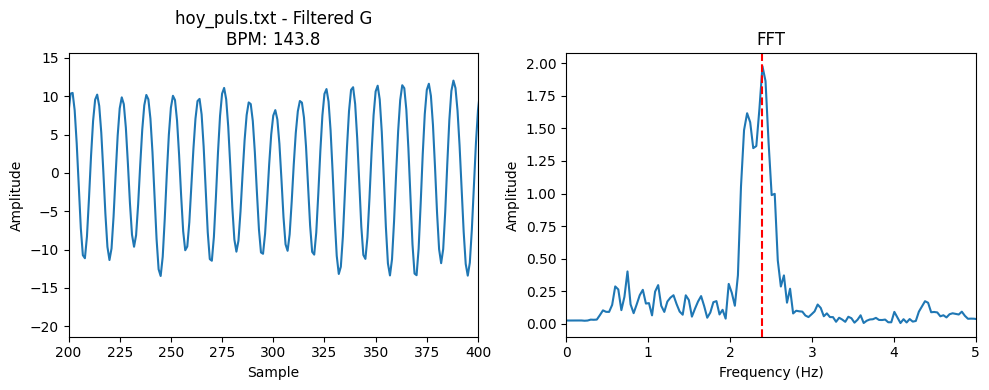

Mean BPM: 143.82022471910113
Std BPM: 0.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

fs = 30
lowcut = 0.5
highcut = 4

files = ["hoy_puls.txt"]

b, a = butter(3, [lowcut/(fs/2), highcut/(fs/2)], btype='band')
bpms = []


for filename in files:

    data = np.loadtxt(filename)
    G = data[:,1]

    G_ac = G - np.mean(G)
    G_ac = G_ac[3*fs:]
    G_filt = filtfilt(b, a, G_ac)

    N = len(G_filt)
    freqs = np.fft.rfftfreq(N, 1/fs)
    fft_vals = np.abs(np.fft.rfft(G_filt)) / N

    mask = (freqs >= 0.5) & (freqs <= 4)
    freqs_band = freqs[mask]
    fft_band = fft_vals[mask]

    peak_freq = freqs_band[np.argmax(fft_band)]
    bpm = peak_freq * 60
    bpms.append(bpm)


    plt.figure(figsize=(10,4))


    plt.subplot(1,2,1)
    plt.plot(G_filt)
    plt.title(f"{filename} - Filtered G\nBPM: {bpm:.1f}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.xlim(200,400)

    
    plt.subplot(1,2,2)
    plt.plot(freqs, fft_vals)
    plt.xlim(0,5)
    plt.axvline(peak_freq, color='r', linestyle='--')
    plt.title("FFT")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

print("Mean BPM:", np.mean(bpms))
print("Std BPM:", np.std(bpms))


**Målte ca. 120 puls litt etter video-opptak**

Segment 1: 148.3 bpm
Segment 2: 141.6 bpm
Segment 3: 128.1 bpm


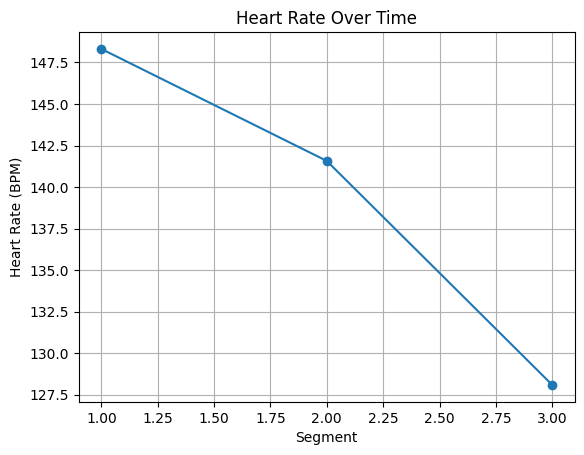

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

fs = 30
lowcut = 0.5
highcut = 4
filename = "hoy_puls.txt"

data = np.loadtxt(filename)
G = data[:,1]

G = G[3*fs:]
G = G - np.mean(G)

b, a = butter(3, [lowcut/(fs/2), highcut/(fs/2)], btype='band')
G_filt = filtfilt(b, a, G)

N = len(G_filt)
num_segments = 3
segment_length = N // num_segments

segments = [G_filt[i*segment_length:(i+1)*segment_length] for i in range(num_segments)]

def estimate_bpm(signal):
    N = len(signal)
    freqs = np.fft.rfftfreq(N, 1/fs)
    fft_vals = np.abs(np.fft.rfft(signal)) / N
    mask = (freqs >= 0.5) & (freqs <= 4)
    freqs_band = freqs[mask]
    fft_band = fft_vals[mask]
    peak_freq = freqs_band[np.argmax(fft_band)]
    return peak_freq * 60

bpms = []

for i, segment in enumerate(segments):
    bpm = estimate_bpm(segment)
    bpms.append(bpm)
    print(f"Segment {i+1}: {bpm:.1f} bpm")

plt.plot(range(1, num_segments+1), bpms, marker='o')
plt.xlabel("Segment")
plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate Over Time")
plt.grid(True)
plt.show()


In [9]:
def compute_snr(signal, fs):

    N = len(signal)

    freqs = np.fft.rfftfreq(N, 1/fs)
    fft_vals = np.abs(np.fft.rfft(signal)) / N

    
    mask = (freqs >= 0.5) & (freqs <= 4)

    freqs_band = freqs[mask]
    fft_band = fft_vals[mask]

    
    peak_idx = np.argmax(fft_band)
    peak_freq = freqs_band[peak_idx]
    peak_amp = fft_band[peak_idx]

    
    exclude = 0.1
    noise_mask = np.abs(freqs_band - peak_freq) > exclude
    noise_vals = fft_band[noise_mask]

    noise_mean = np.mean(noise_vals)

    snr_linear = peak_amp / noise_mean
    snr_db = 20 * np.log10(snr_linear)

    bpm = peak_freq * 60

    return bpm, snr_linear, snr_db

bpm_G, snr_G, snr_G_db = compute_snr(G_filt, fs)


print("G: BPM =", f"{bpm_G:.1f}", "SNR =", f"{snr_G_db:.1f}", "dB")


G: BPM = 143.8 SNR = 18.9 dB
